In [162]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('all_runs_combined.csv')

# Fix column names in DataFrame
def fix_column_names(df):
    df.columns = [col.replace('_', ' ').title() for col in df.columns]


def fix_table_headers(df: pd.DataFrame):
    new_columns = []
    for col in df.columns:
        if isinstance(col, tuple):
            metric, stat = col
            if metric == 'Num Batches':
                new_columns.append((metric, ''))  # Remove 'mean' from second level
            else:
                new_columns.append((metric, stat.capitalize()))  # Capitalize 
        else:
            new_columns.append(col)  
    df.columns = pd.MultiIndex.from_tuples(
        new_columns if isinstance(new_columns[0], tuple) else [(c, '') for c in new_columns]
    )


fix_column_names(df)

# A summary table for each dataset
with open("summary_tables.md", "w") as f:
    for dataset_name in df['Dataset'].unique():
        f.write(f"## Dataset: {dataset_name}\n\n")
        df_subset = df[df['Dataset'] == dataset_name]
        summary = df_subset.groupby(['Batch Size', 'Technique']).agg({
            'Accuracy': ['mean', 'std'],
            'F1': ['mean', 'std'],
            'Precision': ['mean', 'std'],
            'Recall': ['mean', 'std'],
            'Num Drifts' : ['mean'],
            'Num Batches' : ['mean'],
        }).reset_index().sort_values(('F1', 'mean'), ascending=False)
        fix_table_headers(summary)
        f.write(summary.to_markdown(index=False))
        f.write("\n\n---\n\n")

df_subset

,Dataset,Batch Size,Technique,Accuracy,Precision,Recall,F1,Num Drifts,Num Batches,Auc,Drift Alignment With Batch,Scenario,Type Of Dataset,Algorithm,Run Id,Algorithm Seed
80,synthetic_dataset_no_drifts,1000,Base,0.730287,0.730753,0.730287,0.730154,0,80,0.730293,1.0,no_drifts,synthetic,NB,23,23042
81,synthetic_dataset_no_drifts,1000,KS95,0.732600,0.732864,0.732600,0.732526,6,80,0.732604,1.0,no_drifts,synthetic,NB,23,23042
82,synthetic_dataset_no_drifts,1000,KS90,0.732612,0.732945,0.732612,0.732519,16,80,0.732617,1.0,no_drifts,synthetic,NB,23,23042
83,synthetic_dataset_no_drifts,1000,HD,0.732725,0.732917,0.732725,0.732671,4,80,0.732729,1.0,no_drifts,synthetic,NB,23,23042
84,synthetic_dataset_no_drifts,1000,JS,0.732725,0.732917,0.732725,0.732671,4,80,0.732729,1.0,no_drifts,synthetic,NB,23,23042
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3095,synthetic_dataset_no_drifts,2500,Base,0.886587,0.886960,0.886587,0.886559,0,32,0.886581,1.0,no_drifts,synthetic,NB,5,5042
3096,synthetic_dataset_no_drifts,2500,KS95,0.885325,0.885476,0.885325,0.885313,2,32,0.885321,1.0,no_drifts,synthetic,NB,5,5042
3097,synthetic_dataset_no_drifts,2500,KS90,0.887088,0.887249,0.887088,0.887075,5,32,0.887083,1.0,no_drifts,synthetic,NB,5,5042
3098,synthetic_dataset_no_drifts,2500,HD,0.885813,0.885992,0.885813,0.885799,2,32,0.885808,1.0,no_drifts,synthetic,NB,5,5042


In [ ]:
import sys
import os


project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
sys.path.append(project_root)

from codes.name_mapper import synthetic_dataset_name_mapping


def get_dataset_name(dataset):
    return synthetic_dataset_name_mapping.get(dataset, dataset)

def plot_boxplot_and_jitter(df_subset, dataset_name: str = ""):
    if dataset_name is "":
        dataset_name = 'All Datasets'

    plt.figure(figsize=(12, 8))
    sns.boxplot(
        data=df_subset,
        x='Technique',
        y='F1',
        order=df_subset['Technique'].unique(),
        palette="pastel"
    )
    sns.stripplot(
        data=df_subset,
        x='Technique',
        y='F1',
        order=df_subset['Technique'].unique(),
        color='black',
        hue='Batch Size',
        palette="coolwarm",
        jitter=0.1,
        alpha=0.7
    )
    plt.title('F1-Scores per Technique for {}'.format(get_dataset_name(dataset_name)), fontsize=16)
    plt.xlabel('Technique')
    plt.ylabel('Mean F1-Score')
    plt.legend()
    plt.tight_layout()

<>:17: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
<>:17: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
/var/folders/5f/sx30p29n23d2bq0_yfm62z4h0000gn/T/ipykernel_8244/783097605.py:17: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  if dataset_name is "":


/var/folders/5f/sx30p29n23d2bq0_yfm62z4h0000gn/T/ipykernel_8244/449508038.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/5f/sx30p29n23d2bq0_yfm62z4h0000gn/T/ipykernel_8244/449508038.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/5f/sx30p29n23d2bq0_yfm62z4h0000gn/T/ipykernel_8244/449508038.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/5f/sx30p29n23d2bq0_yfm62z4h0000gn/T/ipykernel_8244/449508038.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will 

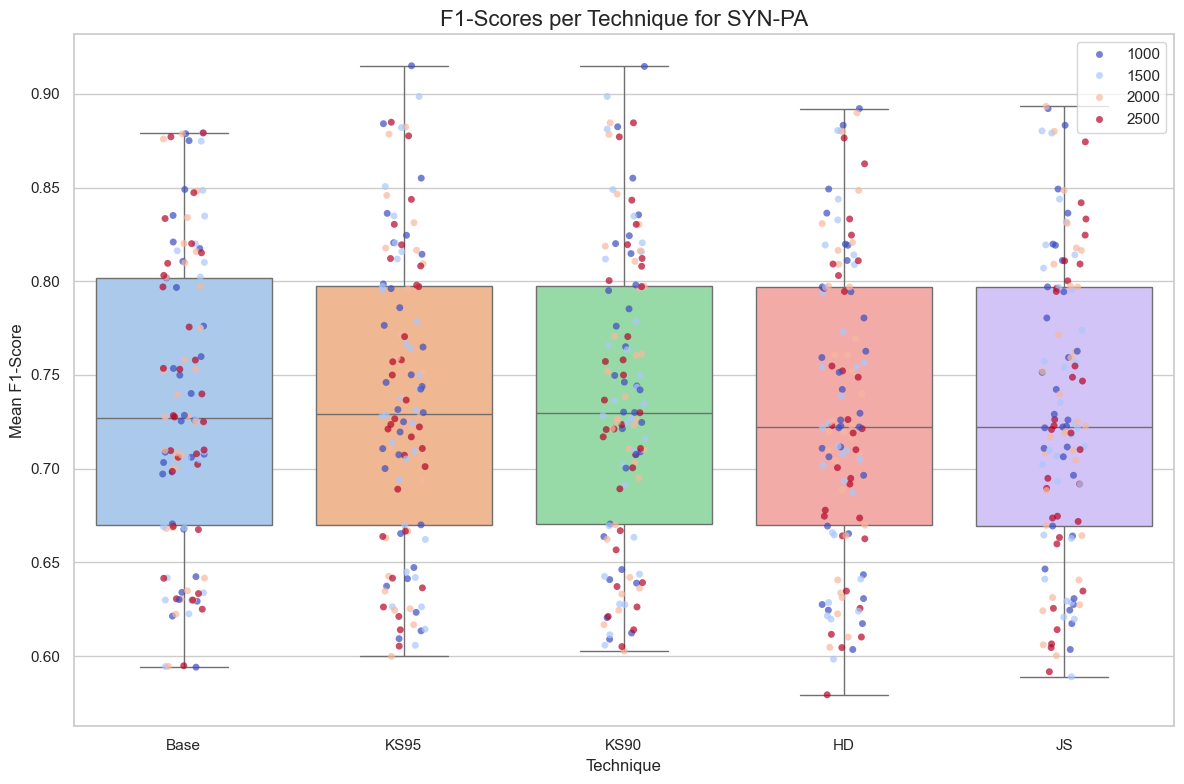

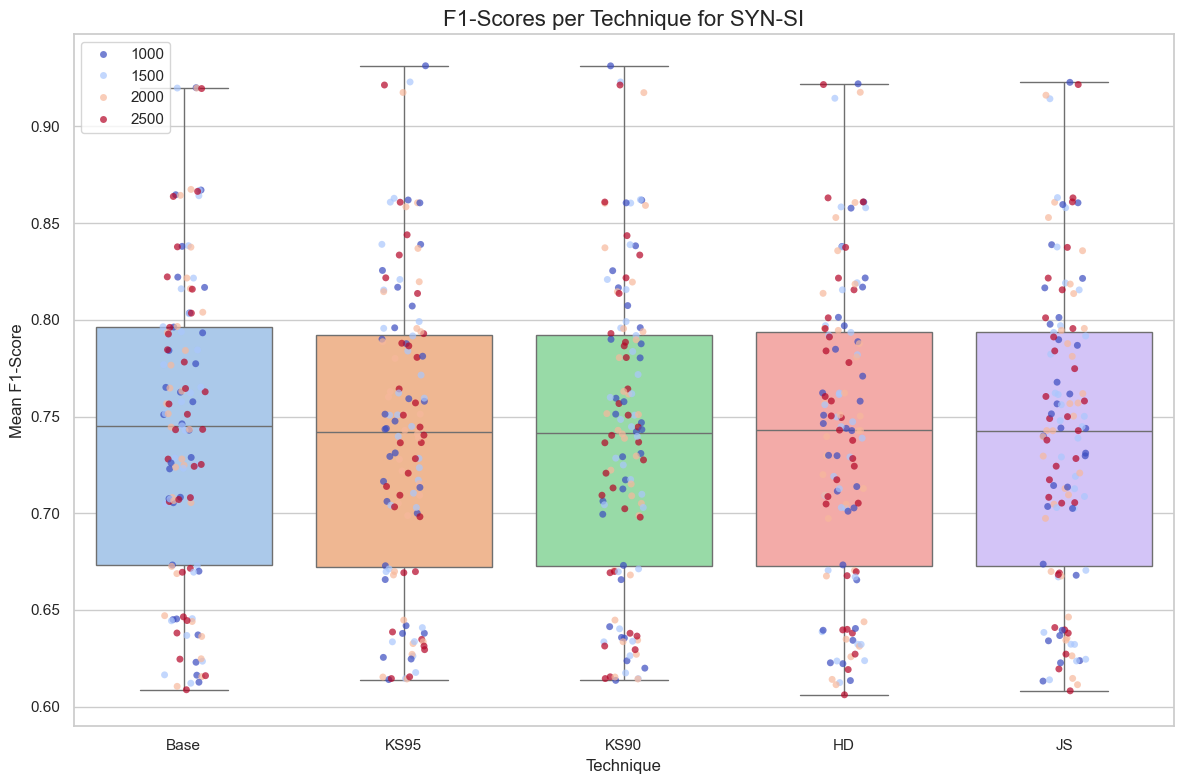

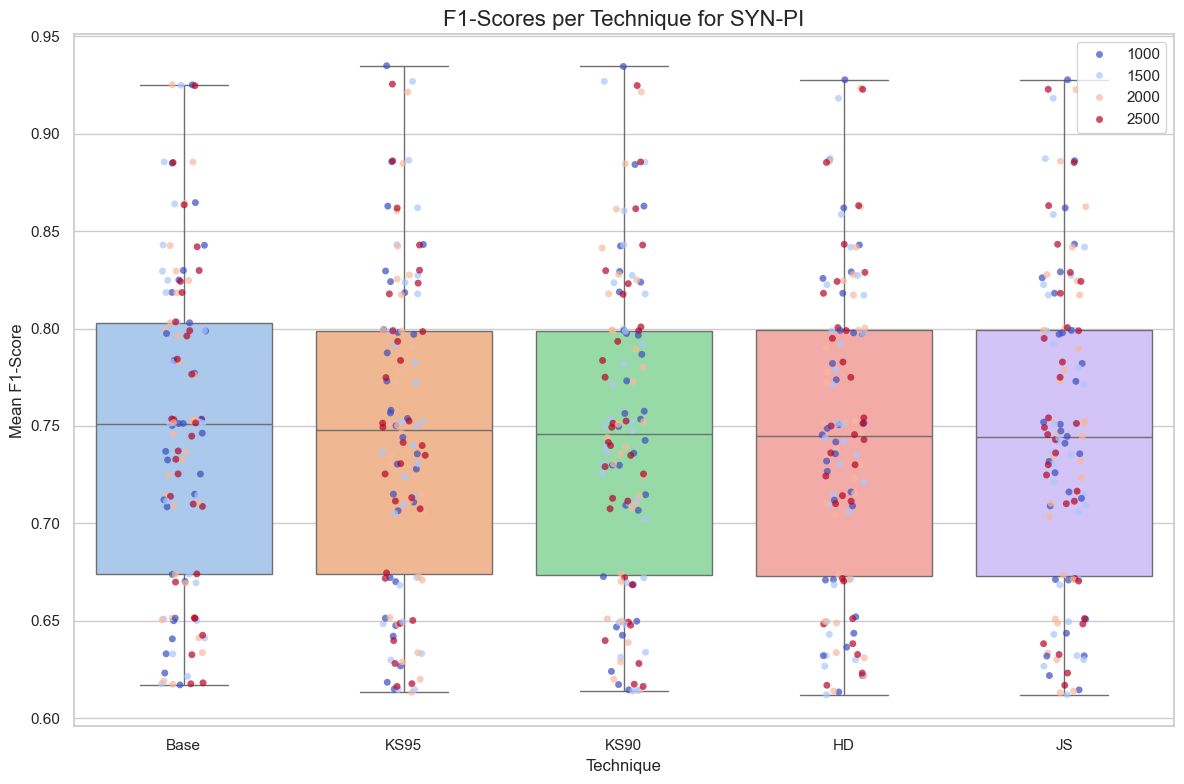

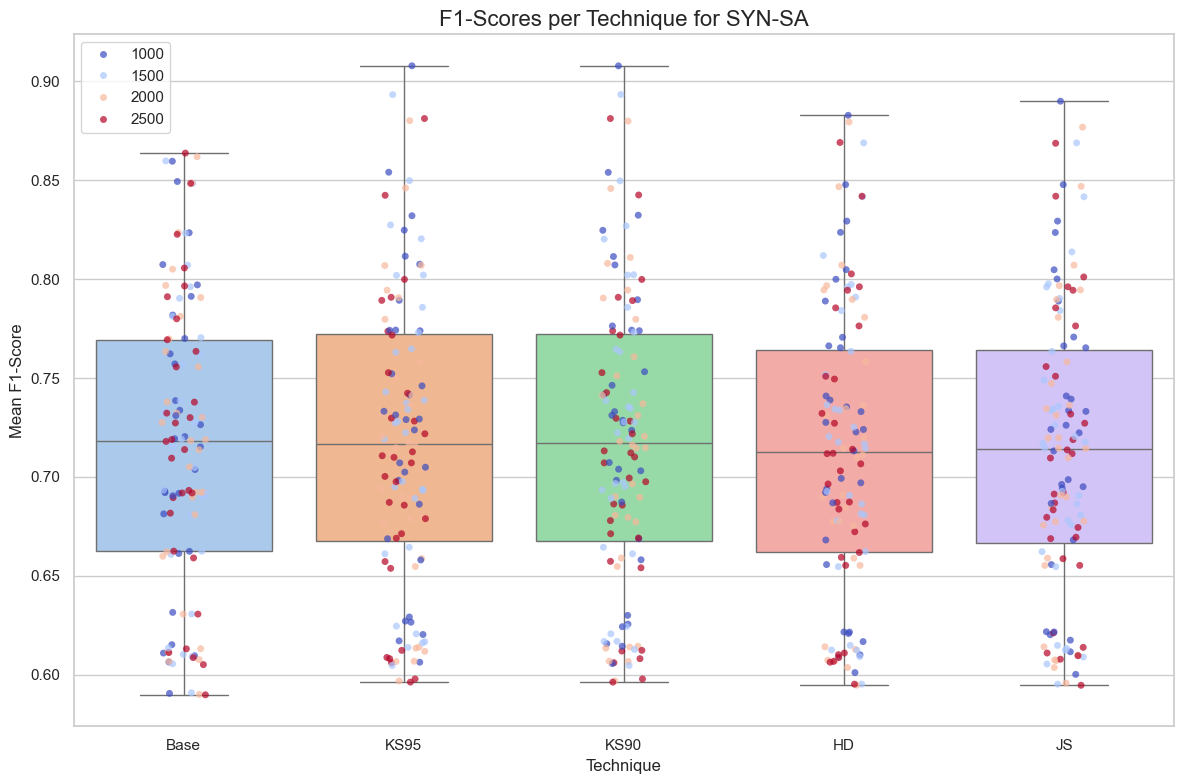

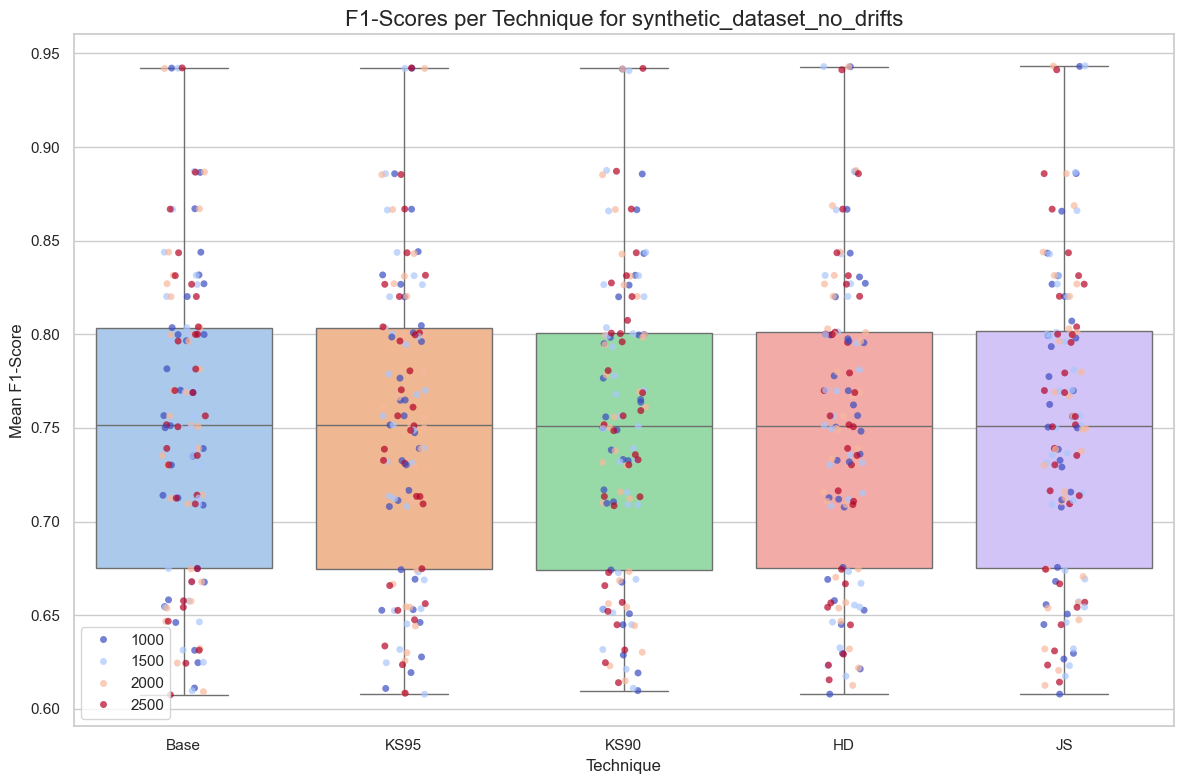

In [129]:
for dataset_name in df['Dataset'].unique():
    # for batch_size in df['Batch Size'].unique():
    df_subset = df[df['Dataset'] == dataset_name]
    # df_subset = df_subset[df_subset['Batch Size'] == batch_size]
    plot_boxplot_and_jitter(df_subset, dataset_name)


# Plots for the average performances

In [148]:
# Write a summary table for all data combined (not split by dataset)
with open("summary_tables_all.md", "w") as f:
    summary = df.groupby(['Batch Size', 'Technique', 'Dataset']).agg({
        'Accuracy': ['mean', 'std'],
        'F1': ['mean', 'std'],
        'Precision': ['mean', 'std'],
        'Recall': ['mean', 'std'],
        'Num Drifts' : ['mean'],
        'Num Batches' : ['mean'],
    }).reset_index().sort_values(('F1', 'mean'), ascending=False)
    fix_table_headers(summary)
    f.write("# Summary Table: All Datasets Combined\n\n")
    f.write(summary.to_markdown(index=False))
    f.write("\n\n---\n\n")

In [149]:
# --- Data Preparation ---
# The 'summary' DataFrame is already loaded.
# We just need to flatten the MultiIndex columns for easier plotting.
summary.columns = ['_'.join(col).strip('_') for col in summary.columns.values]

# Ensure data is sorted for consistent plotting order
summary = summary.sort_values(by=['Batch Size', 'Technique']).reset_index(drop=True)

In [155]:
# Set the overall plot style
sns.set_theme(style="whitegrid")

# Get unique values for creating the plot grid
batch_sizes = sorted(summary['Batch Size'].unique())
techniques = sorted(summary['Technique'].unique())
n_batch_sizes = len(batch_sizes)


Generating Plot: Performance vs. Drifts Scatter Plot...


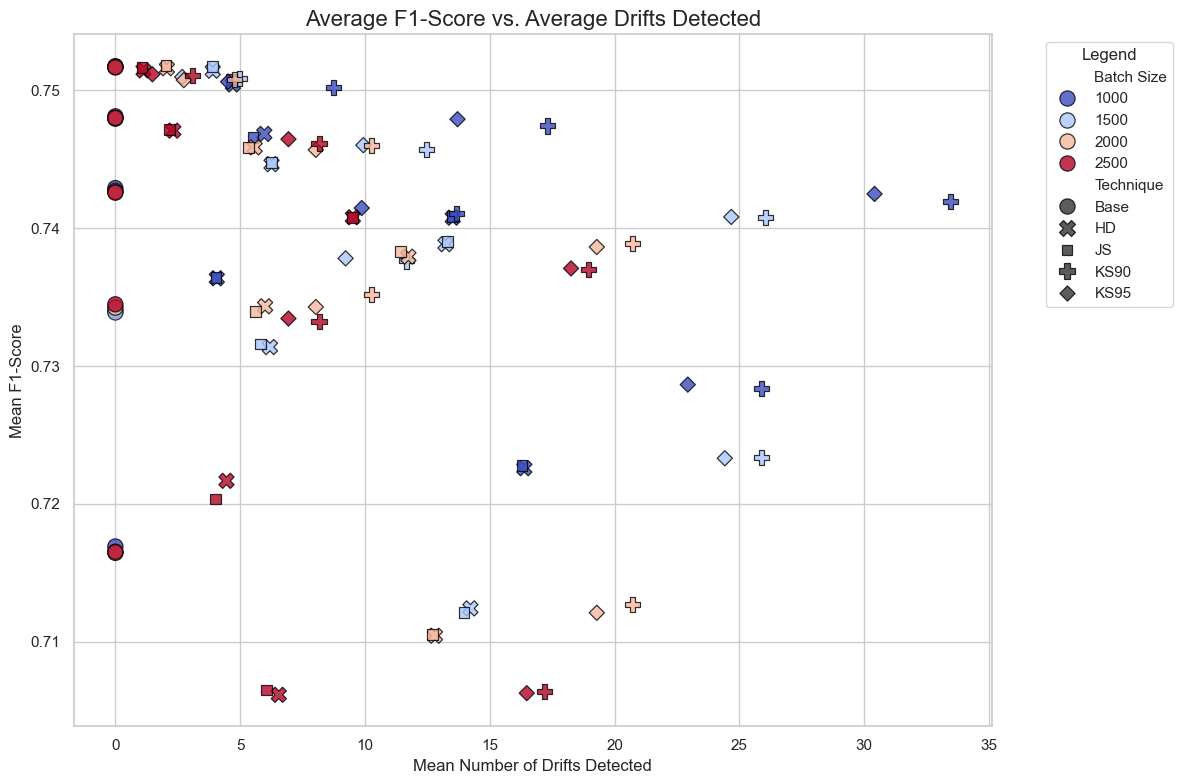

Saved plot2_performance_vs_drifts.png


<Figure size 640x480 with 0 Axes>

In [160]:
# --- Plot: Performance vs. Number of Drifts Detected (Scatter Plot) ---
print("\nGenerating Plot: Performance vs. Drifts Scatter Plot...")

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=summary,
    x='Num Drifts_Mean',
    y='F1_Mean',
    hue='Batch Size',   # Colors now represent batch size
    style='Technique',  # Markers now represent technique
    palette='coolwarm', # Using the palette you requested
    s=120,              # Set a fixed size for all markers for clarity
    alpha=0.8,
    edgecolor='black'
)

plt.title('Average F1-Score vs. Average Drifts Detected', fontsize=16)
plt.xlabel('Mean Number of Drifts Detected')
plt.ylabel('Mean F1-Score')
plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plot2_performance_vs_drifts.png')
plt.show()
plt.clf() # Clear the figure for the next plot
print("Saved plot2_performance_vs_drifts.png")



Generating Plot: Distribution Box Plot...
Saved plot3_distribution_boxplot.png


/var/folders/5f/sx30p29n23d2bq0_yfm62z4h0000gn/T/ipykernel_8244/1194913860.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


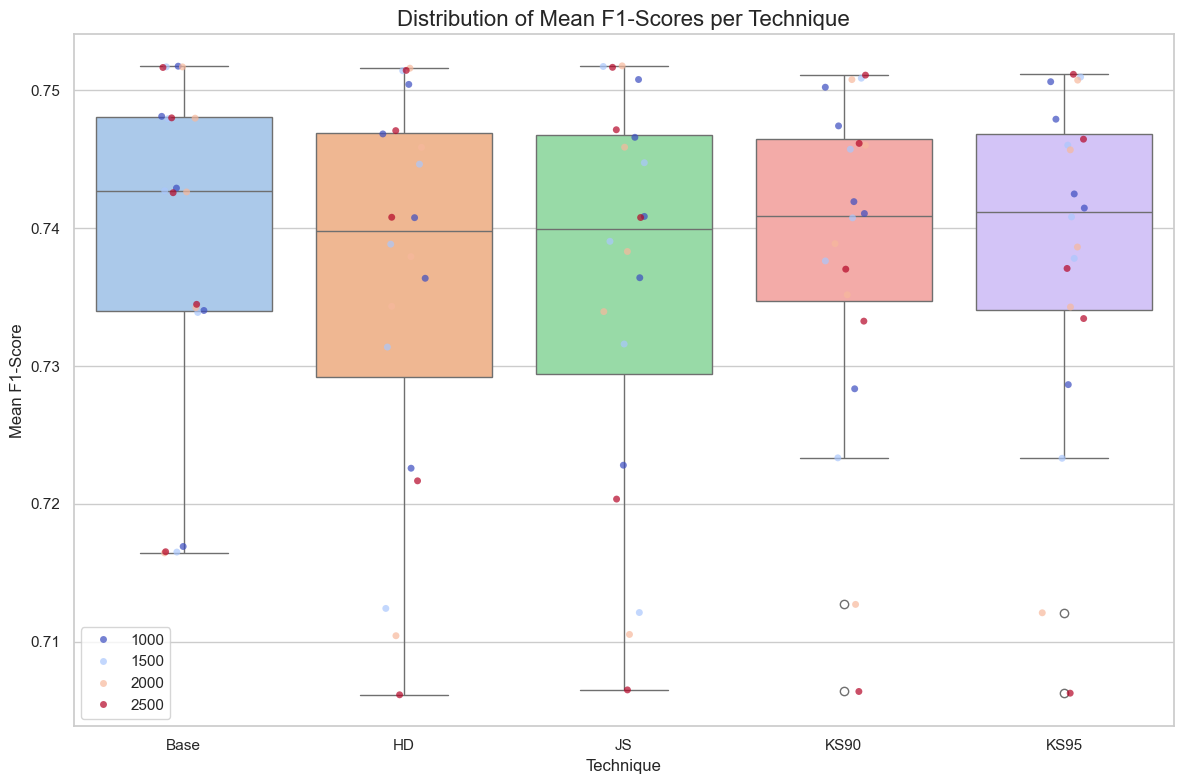

In [161]:
# --- Plot: Aggregated Performance Distribution (Box Plot) ---
print("\nGenerating Plot: Distribution Box Plot...")

plt.figure(figsize=(12, 8))

sns.boxplot(
    data=summary,
    x='Technique',
    y='F1_Mean',
    order=techniques,
    palette="pastel"
)

sns.stripplot(
    data=summary,
    x='Technique',
    y='F1_Mean',
    order=techniques,
    hue='Batch Size',
    palette="coolwarm",
    jitter=0.1,
    alpha=0.7
)


plt.title('Distribution of Mean F1-Scores per Technique', fontsize=16)
plt.xlabel('Technique')
plt.ylabel('Mean F1-Score')
plt.legend()
plt.tight_layout()
plt.savefig('plot3_distribution_boxplot.png')
print("Saved plot3_distribution_boxplot.png")